In [1]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
# Generate a simple dataset
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [3]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

# Feature map (data embedding)
def feature_map(x):
    for i in range(n_qubits):
        qml.RX(x[i], wires=i)

# Variational circuit
def variational_circuit(weights):
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)
    qml.CNOT(wires=[0, 1])

# Full QNode
@qml.qnode(dev)
def circuit(x, weights):
    feature_map(x)
    variational_circuit(weights)
    return qml.expval(qml.PauliZ(0))  # Binary classification


In [4]:
def vqc_predict(x, weights):
    result = circuit(x, weights)
    return 0 if result >= 0 else 1


In [5]:
weights = np.random.randn(n_qubits, requires_grad=True)

opt = qml.GradientDescentOptimizer(stepsize=0.1)
epochs = 20

for epoch in range(epochs):
    for x_i, y_i in zip(X_train, y_train):
        def cost(w):
            pred = circuit(x_i, w)
            return (pred - (1 if y_i == 0 else -1))**2

        weights = opt.step(cost, weights)

    # Compute accuracy
    predictions = [vqc_predict(x, weights) for x in X_train]
    acc = np.mean(predictions == y_train)
    print(f"Epoch {epoch + 1} | Training Accuracy: {acc:.2f}")


Epoch 1 | Training Accuracy: 0.53
Epoch 2 | Training Accuracy: 0.53
Epoch 3 | Training Accuracy: 0.53
Epoch 4 | Training Accuracy: 0.53
Epoch 5 | Training Accuracy: 0.53
Epoch 6 | Training Accuracy: 0.53
Epoch 7 | Training Accuracy: 0.53
Epoch 8 | Training Accuracy: 0.53
Epoch 9 | Training Accuracy: 0.53
Epoch 10 | Training Accuracy: 0.53
Epoch 11 | Training Accuracy: 0.53
Epoch 12 | Training Accuracy: 0.53
Epoch 13 | Training Accuracy: 0.53
Epoch 14 | Training Accuracy: 0.53
Epoch 15 | Training Accuracy: 0.53
Epoch 16 | Training Accuracy: 0.53
Epoch 17 | Training Accuracy: 0.53
Epoch 18 | Training Accuracy: 0.53
Epoch 19 | Training Accuracy: 0.53
Epoch 20 | Training Accuracy: 0.53


In [6]:
test_preds = [vqc_predict(x, weights) for x in X_test]
test_acc = np.mean(test_preds == y_test)
print(f"\nTest Accuracy: {test_acc:.2f}")



Test Accuracy: 0.40


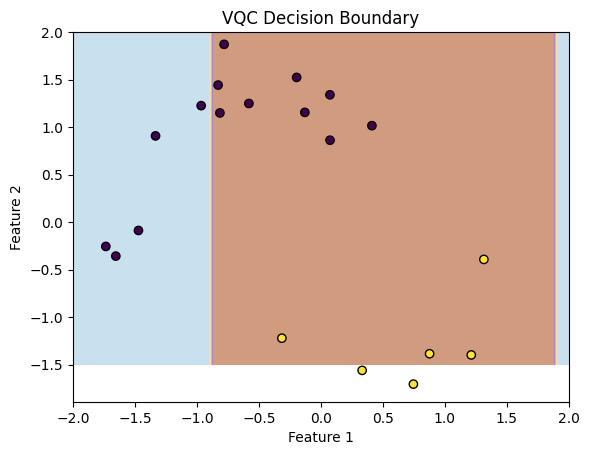

In [7]:
# Grid for plotting
xx, yy = np.meshgrid(np.linspace(-2, 2, 100),
                     np.linspace(-1.5, 2, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([vqc_predict(scaler.transform([point])[0], weights) for point in grid])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k')
plt.title("VQC Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
